# Question 02 — Practical Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    "Area": [800, 1000, 1200, 1400, 1600, 1800,
             2000, 2200, 2400, 2600, 2800, 3000],
    
    "Bedrooms": [2, 2, 2, 3, 3, 3,
                 4, 4, 4, 5, 5, 5],
    
    "Bathrooms": [1, 1, 2, 2, 2, 3,
                  3, 3, 4, 4, 4, 5],
    
    "Price": [44, 54, 65, 83, 88, 107,
              119, 130, 139, 159, 164, 182]
}

df = pd.DataFrame(data)

df

,Area,Bedrooms,Bathrooms,Price
0,800,2,1,44
1,1000,2,1,54
2,1200,2,2,65
3,1400,3,2,83
4,1600,3,2,88
5,1800,3,3,107
6,2000,4,3,119
7,2200,4,3,130
8,2400,4,4,139
9,2600,5,4,159


In [3]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (12, 4)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       12 non-null     int64
 1   Bedrooms   12 non-null     int64
 2   Bathrooms  12 non-null     int64
 3   Price      12 non-null     int64
dtypes: int64(4)
memory usage: 516.0 bytes
None

Missing Values:
Area         0
Bedrooms     0
Bathrooms    0
Price        0
dtype: int64


### Task 1 — Linear Regression with One Variable

In [4]:
x = df["Area"].values / 1000.0
y = df["Price"].values

print("Area:")
print(x)

print("\nPrice:")
print(y)

Area:
[0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3. ]

Price:
[ 44  54  65  83  88 107 119 130 139 159 164 182]


### Split Data into Training and Testing

In [5]:
x_train = x[:9]
x_test = x[9:]

y_train = y[:9]
y_test = y[9:]

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 9
Testing samples: 3


## Define the Cost Function

In [6]:
def compute_cost(x, y, w, b):
    y_pred = w * x + b
    error = y_pred - y
    
    cost = np.mean(error ** 2) / 2
    
    return cost

## Gradient Descent Implementation 

In [7]:
def gradient_descent(x, y, w, b, alpha, iterations):
    
    cost_history = []
    
    for i in range(iterations):
        
        # Prediction
        y_pred = w * x + b
        
        # Error
        error = y_pred - y
        
        # Gradients
        dw = np.mean(error * x)
        db = np.mean(error)
        
        # Update parameters
        w = w - alpha * dw
        b = b - alpha * db
        
        # Store cost
        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)
    
    return w, b, cost_history

## train the Model

In [8]:
w = 0.0
b = 0.0

alpha = 0.05
iterations = 5000

w, b, cost_history = gradient_descent(
    x_train,
    y_train,
    w,
    b,
    alpha,
    iterations
)

print("Slope (w):", w)
print("Intercept (b):", b)
print("Final Cost:", cost_history[-1])

Slope (w): 61.66666631847484
Intercept (b): -6.555554955868525
Final Cost: 3.0123456790123613


### Plot Dataset and Fitted Line

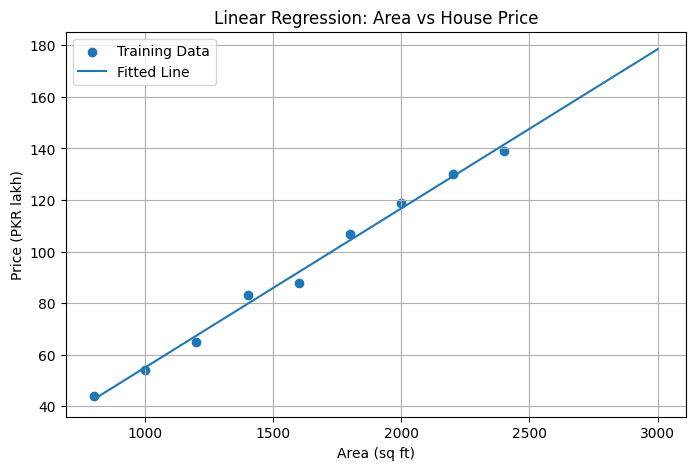

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(x_train * 1000, y_train, label="Training Data")

y_line = w * x + b

plt.plot(x * 1000, y_line, label="Fitted Line")

plt.xlabel("Area (sq ft)")
plt.ylabel("Price (PKR lakh)")
plt.title("Linear Regression: Area vs House Price")

plt.legend()
plt.grid(True)

plt.show()

### Predict Price for 1500 sq ft

In [30]:
area_1500 = 1800 / 1000.0

prediction_1500 = w * area_1500 + b

print("Predicted price for 1500 sq ft:",
      round(prediction_1500, 2),
      "lakh PKR")

Predicted price for 1500 sq ft: 104.44 lakh PKR


In [12]:
### Evaluate Simple Linear Regression

y_pred_test = w * x_test + b

mae = np.mean(np.abs(y_test - y_pred_test))
mse = np.mean((y_test - y_pred_test) ** 2)
rmse = np.sqrt(mse)

ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
ss_residual = np.sum((y_test - y_pred_test) ** 2)

r2 = 1 - (ss_residual / ss_total)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

MAE : 3.63
MSE : 14.79
RMSE: 3.85
R²  : 0.848


### plot cost function convergence 

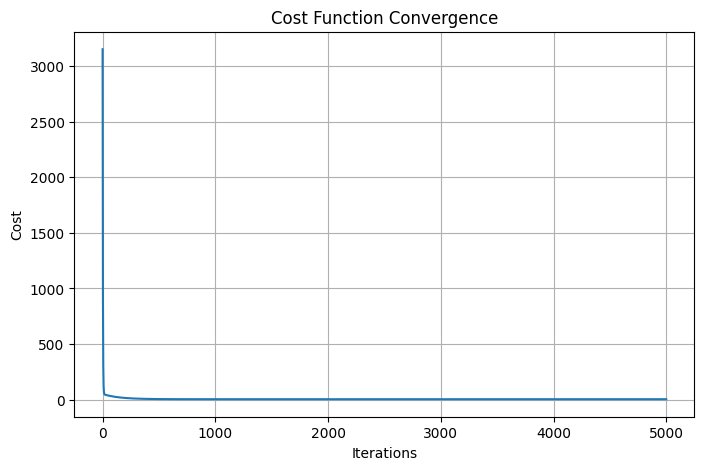

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")

plt.grid(True)

plt.show()

### Experiment with Different Learning Rates

In [14]:
learning_rates = [0.001, 0.01, 0.05, 0.2, 1.0]

results = []

for alpha in learning_rates:
    
    w_temp = 0.0
    b_temp = 0.0
    
    costs = []
    
    for i in range(500):
        
        y_pred = w_temp * x_train + b_temp
        error = y_pred - y_train
        
        dw = np.mean(error * x_train)
        db = np.mean(error)
        
        w_temp = w_temp - alpha * dw
        b_temp = b_temp - alpha * db
        
        cost = np.mean(error ** 2) / 2
        costs.append(cost)
    
    results.append([
        alpha,
        costs[-1]
    ])

results_df = pd.DataFrame(
    results,
    columns=["Learning Rate", "Cost After 500 Iterations"]
)

results_df

c:\Users\Abubakar Sadiq\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Abubakar Sadiq\AppData\Local\Temp\ipykernel_3928\477359397.py:23: RuntimeWarning: overflow encountered in square
  cost = np.mean(error ** 2) / 2


,Learning Rate,Cost After 500 Iterations
0,0.001,157.393887
1,0.010,26.462563
2,0.050,4.381717
3,0.200,3.012376
4,1.000,inf


### Plot Learning Rate Comparison

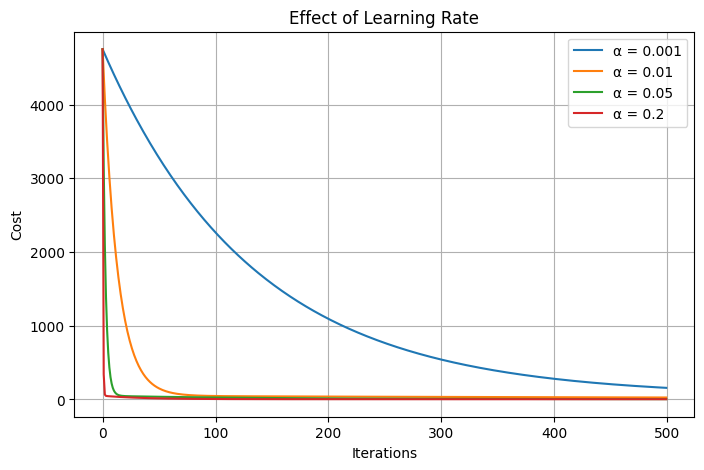

In [15]:
plt.figure(figsize=(8, 5))

for alpha in [0.001, 0.01, 0.05, 0.2]:
    
    w_temp = 0.0
    b_temp = 0.0
    
    costs = []
    
    for i in range(500):
        
        y_pred = w_temp * x_train + b_temp
        error = y_pred - y_train
        
        dw = np.mean(error * x_train)
        db = np.mean(error)
        
        w_temp -= alpha * dw
        b_temp -= alpha * db
        
        costs.append(np.mean(error ** 2) / 2)
    
    plt.plot(costs, label=f"α = {alpha}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Effect of Learning Rate")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
#Discuss Learning Rate
print("Learning Rate Discussion:")
print("0.001 -> Very slow convergence")
print("0.01  -> Faster convergence")
print("0.05  -> Good convergence")
print("0.2   -> Fast convergence")
print("1.0   -> Too large and may diverge")

Learning Rate Discussion:
0.001 -> Very slow convergence
0.01  -> Faster convergence
0.05  -> Good convergence
0.2   -> Fast convergence
1.0   -> Too large and may diverge


## Task 3 —  Select Multiple Features

In [17]:
X = df[["Area", "Bedrooms", "Bathrooms"]].values.astype(float)
y = df["Price"].values.astype(float)

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
[[8.0e+02 2.0e+00 1.0e+00]
 [1.0e+03 2.0e+00 1.0e+00]
 [1.2e+03 2.0e+00 2.0e+00]
 [1.4e+03 3.0e+00 2.0e+00]
 [1.6e+03 3.0e+00 2.0e+00]
 [1.8e+03 3.0e+00 3.0e+00]
 [2.0e+03 4.0e+00 3.0e+00]
 [2.2e+03 4.0e+00 3.0e+00]
 [2.4e+03 4.0e+00 4.0e+00]
 [2.6e+03 5.0e+00 4.0e+00]
 [2.8e+03 5.0e+00 4.0e+00]
 [3.0e+03 5.0e+00 5.0e+00]]

Target:
[ 44.  54.  65.  83.  88. 107. 119. 130. 139. 159. 164. 182.]


### Split Training and Testing Data

In [18]:
X_train = X[:9]
X_test = X[9:]

y_train = y[:9]
y_test = y[9:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9
Testing samples: 3


### Mean Normalization \[
x_{norm}=\frac{x-\text{mean}}{\text{max}-\text{min}}
\]

In [19]:
mean = X_train.mean(axis=0)
range_ = X_train.max(axis=0) - X_train.min(axis=0)

X_train_norm = (X_train - mean) / range_
X_test_norm = (X_test - mean) / range_

print("Feature Means:")
print(mean)

print("\nFeature Ranges:")
print(range_)

print("\nNormalized Training Data:")
print(X_train_norm)

Feature Means:
[1600.            3.            2.33333333]

Feature Ranges:
[1600.    2.    3.]

Normalized Training Data:
[[-0.5        -0.5        -0.44444444]
 [-0.375      -0.5        -0.44444444]
 [-0.25       -0.5        -0.11111111]
 [-0.125       0.         -0.11111111]
 [ 0.          0.         -0.11111111]
 [ 0.125       0.          0.22222222]
 [ 0.25        0.5         0.22222222]
 [ 0.375       0.5         0.22222222]
 [ 0.5         0.5         0.55555556]]


### Implement Multiple Linear Regression Gradient Descent

In [20]:
def multiple_gradient_descent(X, y, alpha, iterations):
    
    theta = np.zeros(X.shape[1] + 1)
    
    cost_history = []
    
    for i in range(iterations):
        
        # Prediction
        y_pred = theta[0] + X @ theta[1:]
        
        # Error
        error = y_pred - y
        
        # Cost
        cost = np.mean(error ** 2) / 2
        cost_history.append(cost)
        
        # Gradients
        grad0 = np.mean(error)
        grad = (X.T @ error) / len(y)
        
        # Update parameters
        theta[0] -= alpha * grad0
        theta[1:] -= alpha * grad
    
    return theta, cost_history

### Train Multiple Linear Regression

In [21]:
alpha = 0.05
iterations = 10000

theta, mlr_cost_history = multiple_gradient_descent(
    X_train_norm,
    y_train,
    alpha,
    iterations
)

print("Parameters:")
print(theta)

Parameters:
[92.11111111 53.5845012  20.0400534  22.24877636]


### Plot Multiple Regression Cost

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(mlr_cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Multiple Linear Regression - Cost Convergence")

plt.grid(True)

plt.show()

### Make Test Predictions

In [22]:
y_pred_mlr = theta[0] + X_test_norm @ theta[1:]

print("Actual Prices:")
print(y_test)

print("\nPredicted Prices:")
print(y_pred_mlr)

Actual Prices:
[159. 164. 182.]

Predicted Prices:
[158.00190907 164.69997172 178.81429316]


### Calculate MLR Evaluation Metrics

In [23]:
mae_mlr = np.mean(np.abs(y_test - y_pred_mlr))

mse_mlr = np.mean((y_test - y_pred_mlr) ** 2)

rmse_mlr = np.sqrt(mse_mlr)

ss_total = np.sum((y_test - np.mean(y_test)) ** 2)

ss_residual = np.sum((y_test - y_pred_mlr) ** 2)

r2_mlr = 1 - (ss_residual / ss_total)

print("Multiple Linear Regression")
print("--------------------------")
print("MAE :", round(mae_mlr, 2))
print("MSE :", round(mse_mlr, 2))
print("RMSE:", round(rmse_mlr, 2))
print("R²  :", round(r2_mlr, 3))

Multiple Linear Regression
--------------------------
MAE : 1.63
MSE : 3.88
RMSE: 1.97
R²  : 0.96


### Compare Simple and Multiple Regression

In [24]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    
    "MAE": [
        mae,
        mae_mlr
    ],
    
    "MSE": [
        mse,
        mse_mlr
    ],
    
    "RMSE": [
        rmse,
        rmse_mlr
    ],
    
    "R2": [
        r2,
        r2_mlr
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression,3.629630,14.790125,3.845793,0.848393
1,Multiple Linear Regression,1.627923,3.878291,1.969338,0.960245


### Normalize Full Dataset

In [26]:
# Cell 26 — Prepare and Normalize Full Dataset

X_all = df[["Area", "Bedrooms", "Bathrooms"]].values.astype(float)
y_all = df["Price"].values.astype(float)

# Calculate mean and range
mean_all = X_all.mean(axis=0)
range_all = X_all.max(axis=0) - X_all.min(axis=0)

# Mean normalization
X_all_norm = (X_all - mean_all) / range_all

print("Mean:")
print(mean_all)

print("\nRange:")
print(range_all)

print("\nNormalized Data:")
print(X_all_norm)

Mean:
[1900.            3.5           2.83333333]

Range:
[2200.    3.    4.]

Normalized Data:
[[-0.5        -0.5        -0.45833333]
 [-0.40909091 -0.5        -0.45833333]
 [-0.31818182 -0.5        -0.20833333]
 [-0.22727273 -0.16666667 -0.20833333]
 [-0.13636364 -0.16666667 -0.20833333]
 [-0.04545455 -0.16666667  0.04166667]
 [ 0.04545455  0.16666667  0.04166667]
 [ 0.13636364  0.16666667  0.04166667]
 [ 0.22727273  0.16666667  0.29166667]
 [ 0.31818182  0.5         0.29166667]
 [ 0.40909091  0.5         0.29166667]
 [ 0.5         0.5         0.54166667]]


### Train Final Model on All Data

In [27]:
alpha = 0.05
iterations = 10000

theta_final, final_cost_history = multiple_gradient_descent(
    X_all_norm,
    y_all,
    alpha,
    iterations
)

print("Final Model Parameters:")
print(theta_final)

Final Model Parameters:
[111.16666667  59.40132943  34.74504473  40.43997536]


### Predict the Required House Price

In [28]:
new_house = np.array([1800, 3, 2], dtype=float)

new_house_norm = (new_house - mean_all) / range_all

predicted_price = (
    theta_final[0] +
    new_house_norm @ theta_final[1:]
)

print(
    "Predicted price for 1800 sq ft, 3 bedrooms, 2 bathrooms:",
    round(predicted_price, 2),
    "lakh PKR"
)

Predicted price for 1800 sq ft, 3 bedrooms, 2 bathrooms: 94.25 lakh PKR


### Final Conclusion

In [29]:
print("FINAL CONCLUSION")
print("----------------")
print("Simple Linear Regression uses only area.")
print("Multiple Linear Regression uses area, bedrooms, and bathrooms.")
print("The multiple-feature model gives a better fit on this dataset.")
print("Predicted price for the required house is approximately")
print("PKR 94.25 lakh.")

FINAL CONCLUSION
----------------
Simple Linear Regression uses only area.
Multiple Linear Regression uses area, bedrooms, and bathrooms.
The multiple-feature model gives a better fit on this dataset.
Predicted price for the required house is approximately
PKR 94.25 lakh.


In [31]:
# Predict house price
area = 1800
bedrooms = 3
bathrooms = 2

new_house = np.array([area, bedrooms, bathrooms], dtype=float)

# Normalize using the training dataset statistics
new_house_norm = (new_house - mean_all) / range_all

# Make prediction
prediction = theta_final[0] + new_house_norm @ theta_final[1:]

print(f"For Area = {area} sq ft, Bedrooms = {bedrooms}, Bathrooms = {bathrooms},")
print(f"the model predicts a house price of {prediction:.2f} lakh PKR.")

For Area = 1800 sq ft, Bedrooms = 3, Bathrooms = 2,
the model predicts a house price of 94.25 lakh PKR.
